# 05 — Grasp Planning con Diffusion Policy

**TFM: Estimación de Pose 6-DoF para Bin Picking Robótico**

Este notebook demuestra:
1. El scheduler DDPM (forward/reverse diffusion)
2. La arquitectura ConditionalUNet1D
3. Generación de trayectorias de agarre heurísticas
4. Generación multimodal con Diffusion Policy (untrained)
5. Visualización 3D de trayectorias

**Ejecutable localmente** en M1 Pro (no requiere GPU NVIDIA)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import sys
sys.path.insert(0, '..')

from src.utils.lie_groups import so3_exp, se3_exp, pose_from_Rt
from src.utils.rotations import matrix_to_6d, sixd_to_matrix
from src.planning.diffusion_policy import (
    SimpleDDPMScheduler,
    ConditionalUNet1D,
    SinusoidalPosEmb,
    DiffusionGraspPlanner,
)

np.random.seed(42)
torch.manual_seed(42)
print('Modules loaded!')

Modules loaded!


## 1. DDPM Scheduler — Forward & Reverse Process

El proceso de difusión añade ruido gaussiano progresivamente (forward),
y luego aprende a revertirlo (reverse) para generar datos nuevos.

$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}\, x_0, (1 - \bar{\alpha}_t)\, \mathbf{I})$$

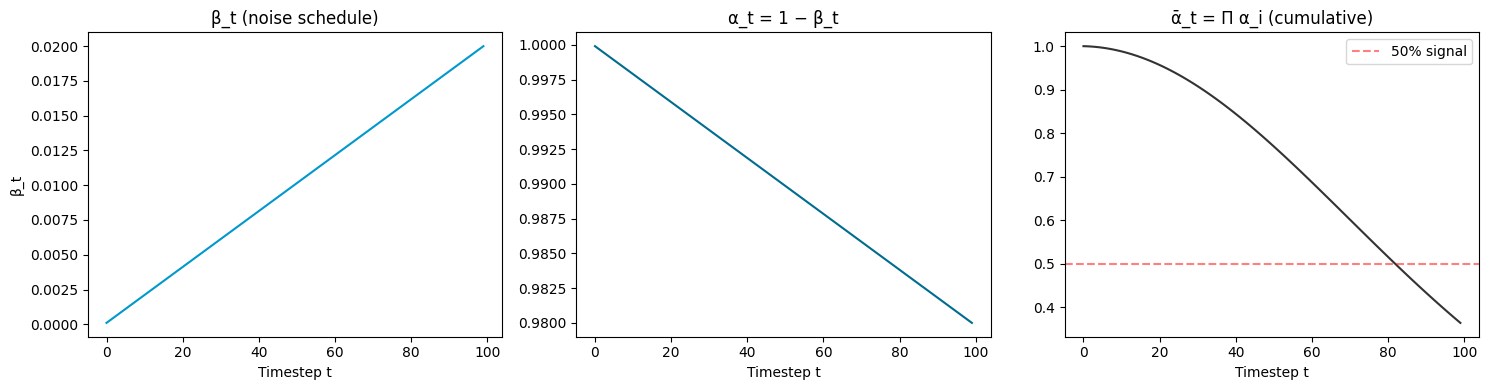

ᾱ_0 = 0.9999, ᾱ_T = 0.363563


In [2]:
scheduler = SimpleDDPMScheduler(num_timesteps=100)

# Visualizar schedule de ruido
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(scheduler.betas, color='#0098CD')
axes[0].set_title('β_t (noise schedule)')
axes[0].set_xlabel('Timestep t')
axes[0].set_ylabel('β_t')

axes[1].plot(scheduler.alphas, color='#006C8F')
axes[1].set_title('α_t = 1 − β_t')
axes[1].set_xlabel('Timestep t')

axes[2].plot(scheduler.alpha_bar, color='#333333')
axes[2].set_title('ᾱ_t = Π α_i (cumulative)')
axes[2].set_xlabel('Timestep t')
axes[2].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='50% signal')
axes[2].legend()

plt.tight_layout()
plt.savefig('../experiments/ddpm_schedule.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ᾱ_0 = {scheduler.alpha_bar[0]:.4f}, ᾱ_T = {scheduler.alpha_bar[-1]:.6f}')

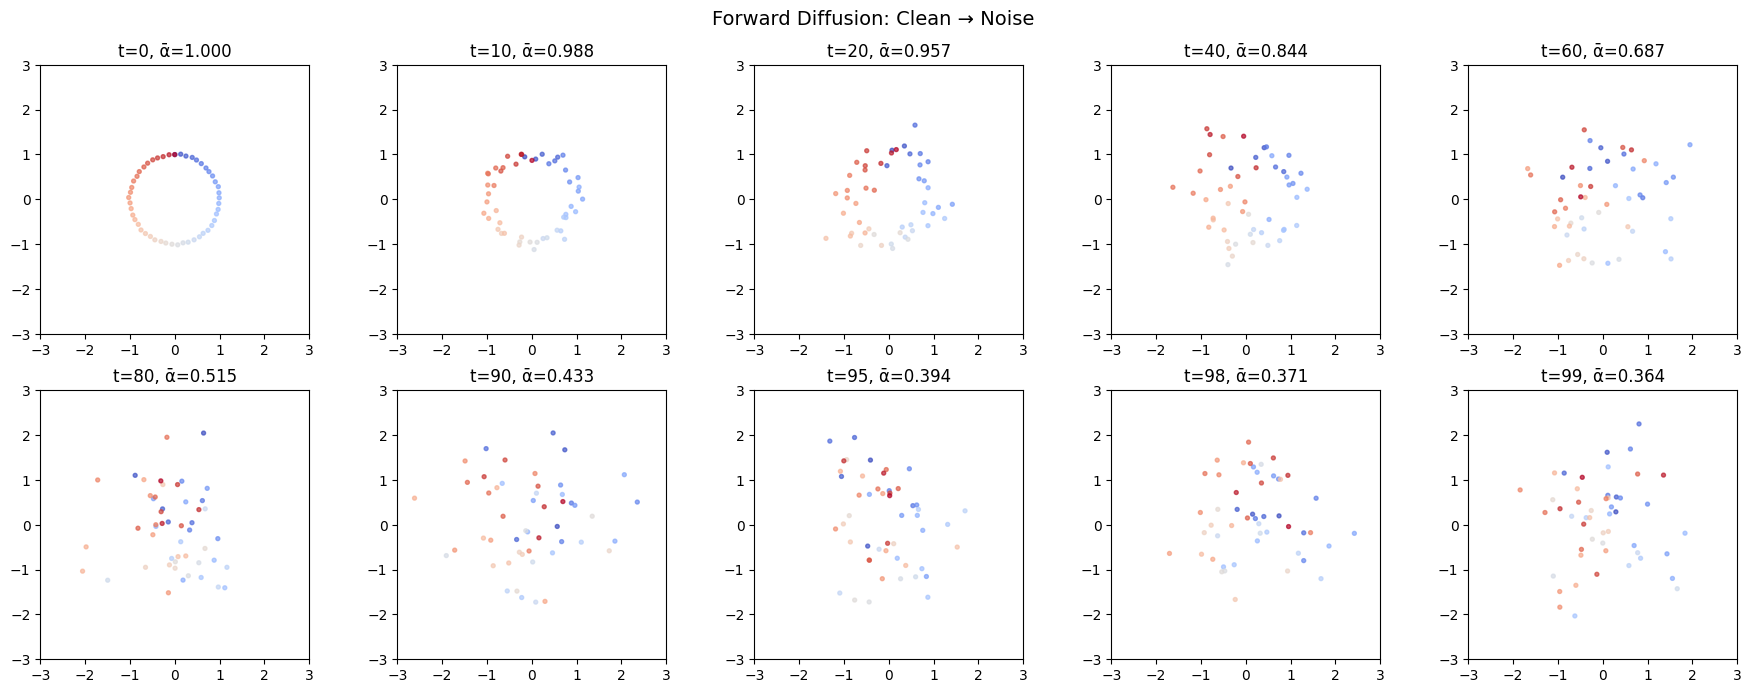

In [3]:
# Demostración: Forward diffusion sobre una trayectoria 1D
t_steps = np.linspace(0, 2*np.pi, 50)
clean_trajectory = np.column_stack([np.sin(t_steps), np.cos(t_steps)])

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
timesteps = [0, 10, 20, 40, 60, 80, 90, 95, 98, 99]

for idx, t in enumerate(timesteps):
    row, col = idx // 5, idx % 5
    noisy, eps = scheduler.add_noise(clean_trajectory, t)
    axes[row, col].scatter(noisy[:, 0], noisy[:, 1], s=8, c=range(len(noisy)),
                           cmap='coolwarm', alpha=0.7)
    axes[row, col].set_title(f't={t}, ᾱ={scheduler.alpha_bar[t]:.3f}')
    axes[row, col].set_xlim(-3, 3)
    axes[row, col].set_ylim(-3, 3)
    axes[row, col].set_aspect('equal')

fig.suptitle('Forward Diffusion: Clean → Noise', fontsize=14)
plt.tight_layout()
plt.savefig('../experiments/forward_diffusion_demo.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. ConditionalUNet1D — Arquitectura

La red U-Net 1D predice el ruido $\epsilon_\theta(x_t, t, c)$ dado:
- $x_t$: trayectoria ruidosa (horizon × action_dim)
- $t$: timestep de difusión
- $c$: condición (pose del objeto, observación RGB-D)

In [4]:
# Instanciar el modelo
model = ConditionalUNet1D(
    action_dim=7,      # [x, y, z, rx, ry, rz, gripper]
    horizon=16,         # 16 waypoints
    cond_dim=64,        # observación codificada
    hidden_dim=128,
)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Model size: ~{total_params * 4 / 1024 / 1024:.1f} MB (float32)')
print()

# Forward pass test
B = 4  # batch size
x = torch.randn(B, 16, 7)     # noisy trajectories
t = torch.randint(0, 100, (B,))  # timesteps
c = torch.randn(B, 64)         # conditions

eps_pred = model(x, t, c)
print(f'Input:  x={x.shape}, t={t.shape}, c={c.shape}')
print(f'Output: eps_pred={eps_pred.shape}')
assert eps_pred.shape == x.shape, 'Output shape must match input!'
print('✓ Architecture verified!')

Total parameters: 345,991
Trainable parameters: 345,991
Model size: ~1.3 MB (float32)

Input:  x=torch.Size([4, 16, 7]), t=torch.Size([4]), c=torch.Size([4, 64])
Output: eps_pred=torch.Size([4, 16, 7])
✓ Architecture verified!


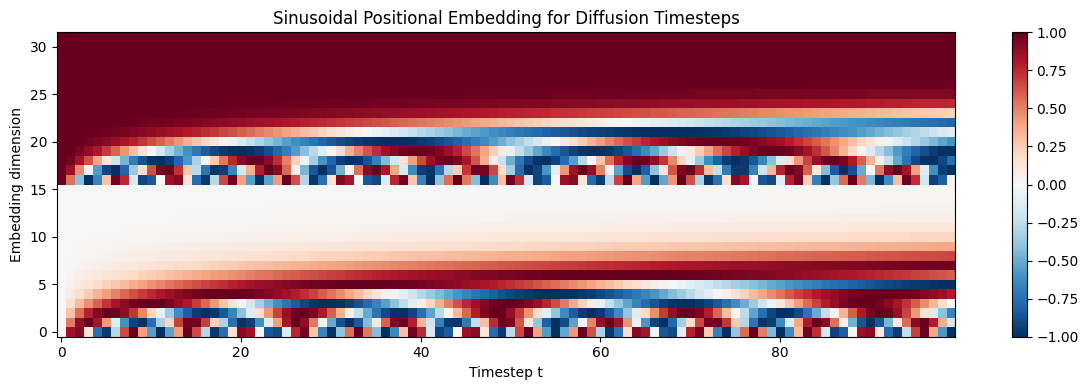

In [5]:
# Sinusoidal positional embedding — visualización
emb = SinusoidalPosEmb(dim=32)
timesteps_vis = torch.arange(100).float()
embeddings = emb(timesteps_vis).detach().numpy()

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(embeddings.T, aspect='auto', cmap='RdBu_r', origin='lower')
ax.set_xlabel('Timestep t')
ax.set_ylabel('Embedding dimension')
ax.set_title('Sinusoidal Positional Embedding for Diffusion Timesteps')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('../experiments/sinusoidal_embedding.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Trayectoria Heurística (Baseline)

Antes de usar difusión, comparamos con un baseline simple:
top-down approach → grasp → lift.

In [6]:
# Crear una pose de objeto ejemplo
R_obj = so3_exp(np.array([0.1, -0.2, 0.3]))  # ligera rotación
t_obj = np.array([0.3, 0.1, 0.05])            # sobre la mesa
object_pose = pose_from_Rt(R_obj, t_obj)

print('Object pose (SE(3)):')
print(object_pose.round(3))
print(f'Position: {t_obj} m')

Object pose (SE(3)):
[[ 0.936 -0.303 -0.181  0.3  ]
 [ 0.283  0.951 -0.127  0.1  ]
 [ 0.21   0.068  0.975  0.05 ]
 [ 0.     0.     0.     1.   ]]
Position: [0.3  0.1  0.05] m


Trajectory shape: (1, 16, 7)
Waypoints: 16


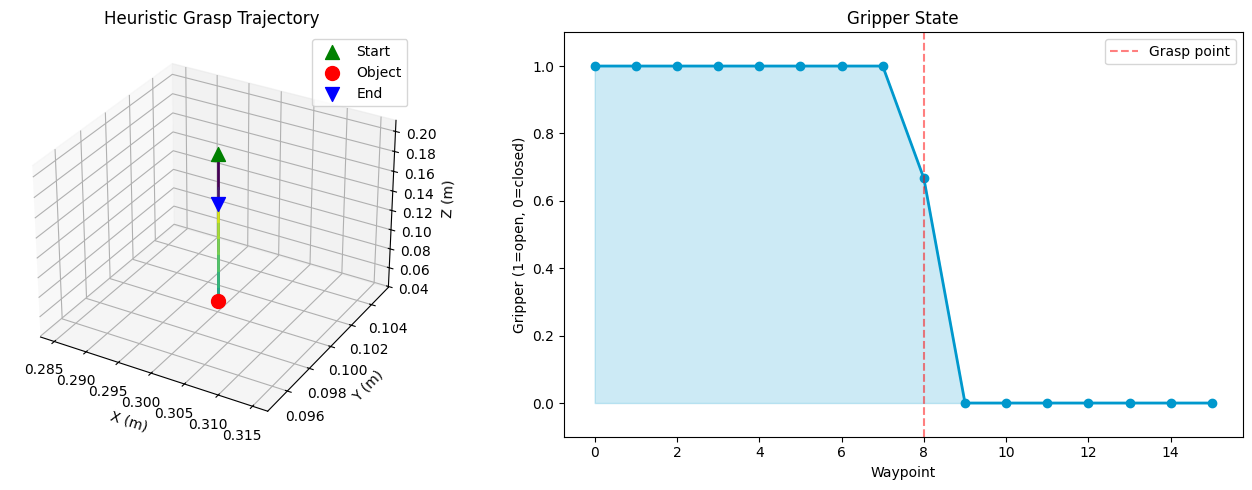

In [7]:
# Generar trayectoria heurística
planner = DiffusionGraspPlanner(action_dim=7, horizon=16)
traj_heuristic = planner.plan_grasp_heuristic(
    object_pose,
    approach_distance=0.15,
    lift_height=0.10
)

print(f'Trajectory shape: {traj_heuristic.shape}')  # (1, 16, 7)
print(f'Waypoints: {traj_heuristic.shape[1]}')

# Extraer componentes
positions = traj_heuristic[0, :, :3]   # (16, 3)
gripper = traj_heuristic[0, :, 6]      # (16,)

# Plot 3D trayectoria
fig = plt.figure(figsize=(14, 5))

# 3D trajectory
ax1 = fig.add_subplot(121, projection='3d')
colors = plt.cm.viridis(np.linspace(0, 1, len(positions)))
for i in range(len(positions) - 1):
    ax1.plot3D(
        positions[i:i+2, 0], positions[i:i+2, 1], positions[i:i+2, 2],
        color=colors[i], linewidth=2
    )
ax1.scatter(*positions[0], color='green', s=100, marker='^', label='Start', zorder=5)
ax1.scatter(*t_obj, color='red', s=100, marker='o', label='Object', zorder=5)
ax1.scatter(*positions[-1], color='blue', s=100, marker='v', label='End', zorder=5)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_zlabel('Z (m)')
ax1.set_title('Heuristic Grasp Trajectory')
ax1.legend()

# Gripper state over time
ax2 = fig.add_subplot(122)
ax2.plot(range(16), gripper, 'o-', color='#0098CD', linewidth=2)
ax2.fill_between(range(16), gripper, alpha=0.2, color='#0098CD')
ax2.set_xlabel('Waypoint')
ax2.set_ylabel('Gripper (1=open, 0=closed)')
ax2.set_title('Gripper State')
ax2.set_ylim(-0.1, 1.1)
ax2.axvline(x=8, color='r', linestyle='--', alpha=0.5, label='Grasp point')
ax2.legend()

plt.tight_layout()
plt.savefig('../experiments/heuristic_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Diffusion Policy — Generación Multimodal

Con el modelo sin entrenar (random weights), la difusión genera
trayectorias aleatorias. Tras el entrenamiento con datos de
demostración, generaría trayectorias multimodales de agarre.

Generated 5 trajectories: (5, 16, 7)


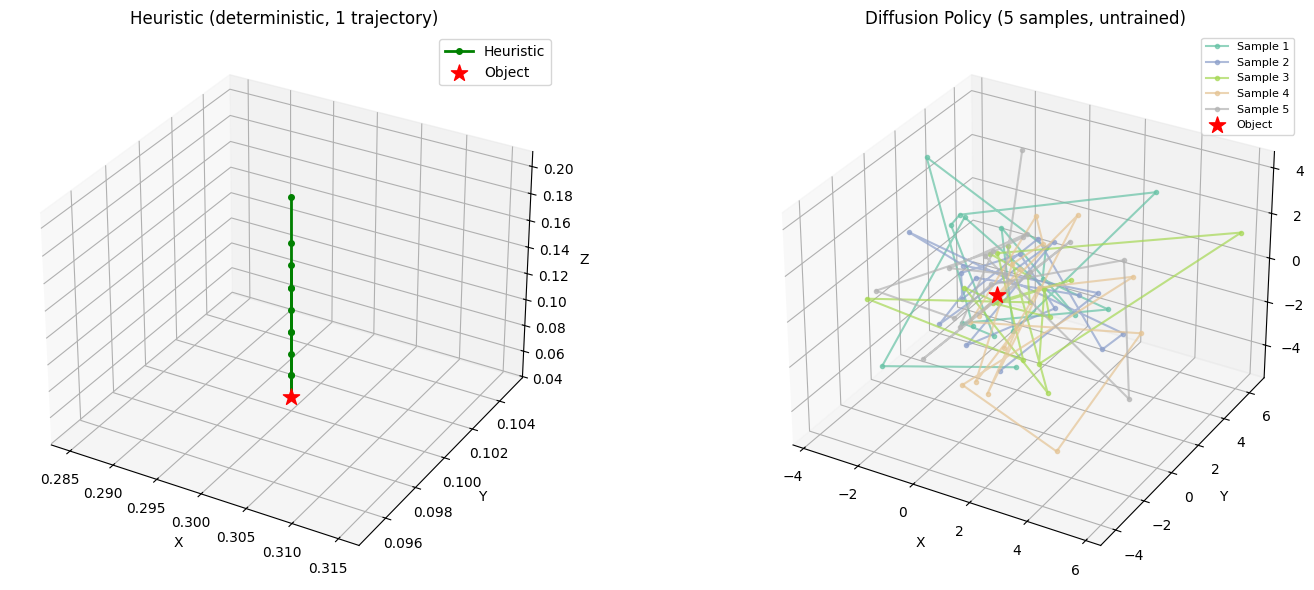


→ Tras entrenamiento, las trayectorias por difusión convergerían
  a agarres válidos pero con diversidad multimodal (diferentes approach angles)


In [8]:
# Generar múltiples trayectorias con diffusion (untrained = random)
n_samples = 5
trajs_diffusion = planner.plan_grasp(object_pose, n_samples=n_samples)
print(f'Generated {n_samples} trajectories: {trajs_diffusion.shape}')

# Comparar: heurística vs difusión
fig = plt.figure(figsize=(16, 6))

# Heuristic
ax1 = fig.add_subplot(121, projection='3d')
pos = traj_heuristic[0, :, :3]
ax1.plot3D(pos[:, 0], pos[:, 1], pos[:, 2], 'g-o', linewidth=2, markersize=4,
           label='Heuristic')
ax1.scatter(*t_obj, color='red', s=150, marker='*', label='Object')
ax1.set_title('Heuristic (deterministic, 1 trajectory)')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.legend()

# Diffusion (multimodal)
ax2 = fig.add_subplot(122, projection='3d')
colors_diff = plt.cm.Set2(np.linspace(0, 1, n_samples))
for i in range(n_samples):
    pos_d = trajs_diffusion[i, :, :3]
    ax2.plot3D(pos_d[:, 0], pos_d[:, 1], pos_d[:, 2],
              '-o', color=colors_diff[i], linewidth=1.5, markersize=3,
              label=f'Sample {i+1}', alpha=0.7)
ax2.scatter(*t_obj, color='red', s=150, marker='*', label='Object')
ax2.set_title(f'Diffusion Policy ({n_samples} samples, untrained)')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../experiments/diffusion_vs_heuristic.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n→ Tras entrenamiento, las trayectorias por difusión convergerían')
print('  a agarres válidos pero con diversidad multimodal (diferentes approach angles)')

## 5. Análisis de Componentes de la Trayectoria

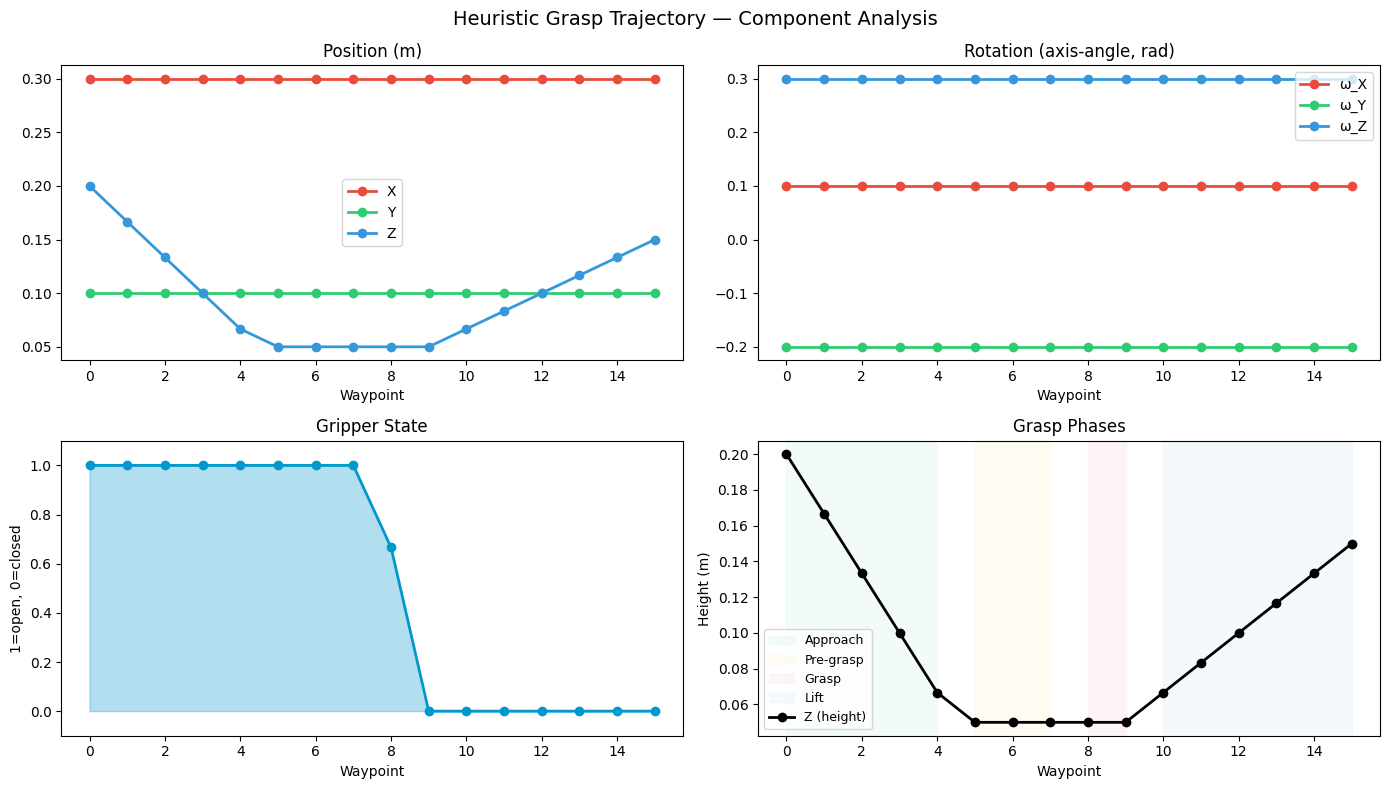

In [9]:
# Desglose temporal de la trayectoria heurística
traj = traj_heuristic[0]  # (16, 7)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Position XYZ
labels = ['X', 'Y', 'Z']
colors_xyz = ['#e74c3c', '#2ecc71', '#3498db']
for i in range(3):
    axes[0, 0].plot(traj[:, i], 'o-', label=labels[i], color=colors_xyz[i], linewidth=2)
axes[0, 0].set_title('Position (m)')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Waypoint')

# Rotation (as axis-angle components)
for i in range(3):
    axes[0, 1].plot(traj[:, 3+i], 'o-', label=f'ω_{labels[i]}', color=colors_xyz[i], linewidth=2)
axes[0, 1].set_title('Rotation (axis-angle, rad)')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Waypoint')

# Gripper
axes[1, 0].fill_between(range(16), traj[:, 6], alpha=0.3, color='#0098CD')
axes[1, 0].plot(traj[:, 6], 'o-', color='#0098CD', linewidth=2)
axes[1, 0].set_title('Gripper State')
axes[1, 0].set_ylabel('1=open, 0=closed')
axes[1, 0].set_xlabel('Waypoint')
axes[1, 0].set_ylim(-0.1, 1.1)

# Phase annotations
phases = {
    'Approach': (0, 4, '#e8f8f5'),
    'Pre-grasp': (5, 7, '#fef9e7'),
    'Grasp': (8, 9, '#fdedec'),
    'Lift': (10, 15, '#ebf5fb'),
}
ax_phase = axes[1, 1]
for phase, (start, end, color) in phases.items():
    ax_phase.axvspan(start, end, alpha=0.5, color=color, label=phase)
ax_phase.plot(traj[:, 2], 'ko-', linewidth=2, label='Z (height)')  # Z component
ax_phase.set_title('Grasp Phases')
ax_phase.set_xlabel('Waypoint')
ax_phase.set_ylabel('Height (m)')
ax_phase.legend(fontsize=9)

plt.suptitle('Heuristic Grasp Trajectory — Component Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('../experiments/trajectory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Resumen y Próximos Pasos

**Lo que tenemos:**
- DDPM scheduler funcional (forward + reverse)
- ConditionalUNet1D para predicción de ruido
- Grasp heurístico como baseline
- Generación multimodal por difusión (untrained)

**Próximos pasos:**
1. Generar datos de entrenamiento en CoppeliaSim (demostraciones de agarre)
2. Entrenar en Colab con GPU T4
3. Evaluar: success rate en simulación (heurístico vs difusión)
4. Integrar con FoundationPose para pipeline completo